In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import pandas as pd
from src.data_loader import load_data_cleaned
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
mattress_df = load_data_cleaned("mattresses_clean.csv")
display(mattress_df)

,product_name,brand,material_type,category,description,rating,reviews,product_sold_number,image_url,link,origin,warranty,firmness,thickness,price,width,length
0,Nệm cao su thiên nhiên Gummi Classic thế hệ mớ...,Gummi,Cao su thiên nhiên,Cao su,"Thương hiệu Gummi - Tinh khiết từ cao su, đúng...",4.9,359.0,44410.0,"https://cdn-cf-ops.vuanem.com/186x186,webp,q80...",https://vuanem.com/nem-cao-su-gummi-classic.ht...,Việt Nam,180.0,Cứng vừa,5.0,6712000,120.0,200.0
1,Nệm cao su thiên nhiên Gummi Classic thế hệ mớ...,Gummi,Cao su thiên nhiên,Cao su,"Thương hiệu Gummi - Tinh khiết từ cao su, đúng...",4.9,359.0,44410.0,"https://cdn-cf-ops.vuanem.com/186x186,webp,q80...",https://vuanem.com/nem-cao-su-gummi-classic.ht...,Việt Nam,180.0,Cứng vừa,10.0,7808000,120.0,200.0
2,Nệm cao su thiên nhiên Gummi Classic thế hệ mớ...,Gummi,Cao su thiên nhiên,Cao su,"Thương hiệu Gummi - Tinh khiết từ cao su, đúng...",4.9,359.0,44410.0,"https://cdn-cf-ops.vuanem.com/186x186,webp,q80...",https://vuanem.com/nem-cao-su-gummi-classic.ht...,Việt Nam,180.0,Cứng vừa,15.0,12608000,120.0,200.0
3,Nệm cao su thiên nhiên Gummi Classic thế hệ mớ...,Gummi,Cao su thiên nhiên,Cao su,"Thương hiệu Gummi - Tinh khiết từ cao su, đúng...",4.9,359.0,44410.0,"https://cdn-cf-ops.vuanem.com/186x186,webp,q80...",https://vuanem.com/nem-cao-su-gummi-classic.ht...,Việt Nam,180.0,Cứng vừa,5.0,7352000,140.0,200.0
4,Nệm cao su thiên nhiên Gummi Classic thế hệ mớ...,Gummi,Cao su thiên nhiên,Cao su,"Thương hiệu Gummi - Tinh khiết từ cao su, đúng...",4.9,359.0,44410.0,"https://cdn-cf-ops.vuanem.com/186x186,webp,q80...",https://vuanem.com/nem-cao-su-gummi-classic.ht...,Việt Nam,180.0,Cứng vừa,10.0,9408000,140.0,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4527,Nệm Cao Su Tổng Hợp Kim Cương,Kim Cương,Cao su tổng hợp,Foam,NỆM CAO SU TỔNG HỢP KIM CƯƠNG Nệm cao su tổng ...,NaN,NaN,NaN,https://bizweb.dktcdn.net/thumb/medium/100/405...,https://thegioigiuongnem.com/nem-cao-su-tong-h...,Việt Nam,120.0,Mềm - Trung bình,22.0,3175000,100.0,200.0
4528,Nệm Cao Su Tổng Hợp Kim Cương,Kim Cương,Cao su tổng hợp,Foam,NỆM CAO SU TỔNG HỢP KIM CƯƠNG Nệm cao su tổng ...,NaN,NaN,NaN,https://bizweb.dktcdn.net/thumb/medium/100/405...,https://thegioigiuongnem.com/nem-cao-su-tong-h...,Việt Nam,120.0,Mềm - Trung bình,22.0,3377000,120.0,200.0
4529,Nệm Cao Su Tổng Hợp Kim Cương,Kim Cương,Cao su tổng hợp,Foam,NỆM CAO SU TỔNG HỢP KIM CƯƠNG Nệm cao su tổng ...,NaN,NaN,NaN,https://bizweb.dktcdn.net/thumb/medium/100/405...,https://thegioigiuongnem.com/nem-cao-su-tong-h...,Việt Nam,120.0,Mềm - Trung bình,22.0,3578000,140.0,200.0
4530,Nệm Cao Su Tổng Hợp Kim Cương,Kim Cương,Cao su tổng hợp,Foam,NỆM CAO SU TỔNG HỢP KIM CƯƠNG Nệm cao su tổng ...,NaN,NaN,NaN,https://bizweb.dktcdn.net/thumb/medium/100/405...,https://thegioigiuongnem.com/nem-cao-su-tong-h...,Việt Nam,120.0,Mềm - Trung bình,22.0,3780000,160.0,200.0


## I. Phân tích đơn biến

In [4]:
num_cols = [
    "rating",
    "reviews",
    "product_sold_number",
    "warranty",
    "price",
    "thickness",
    "width",
    "length"
]

cat_cols = [
    "brand",
    "material_type",
    "category",
    "origin",
    "firmness"
]

In [5]:
mattress_df[num_cols].describe()

,rating,reviews,product_sold_number,warranty,price,thickness,width,length
count,2650.000000,2650.000000,2650.000000,4419.000000,4.532000e+03,4521.000000,4525.000000,4525.000000
mean,4.312981,186.891698,2713.265283,115.326544,9.669327e+06,15.129308,153.807293,199.153812
std,2.877889,591.400091,5536.400920,34.729387,1.179285e+07,8.027049,37.535123,10.814047
min,0.000000,0.000000,0.000000,12.000000,7.200000e+04,2.000000,16.000000,35.000000
25%,4.800000,9.000000,101.000000,96.000000,3.192000e+06,10.000000,120.000000,200.000000
50%,5.000000,48.000000,533.500000,120.000000,5.887000e+06,14.000000,160.000000,200.000000
75%,5.000000,133.000000,3300.000000,120.000000,1.146700e+07,20.000000,180.000000,200.000000
max,21.300000,5100.000000,44410.000000,240.000000,1.576800e+08,39.000000,240.000000,240.000000


In [6]:
mattress_df[num_cols].skew()

rating                 2.662056
reviews                5.953060
product_sold_number    4.336081
warranty               0.071324
price                  4.384425
thickness              0.559381
width                 -0.046474
length                -6.683014
dtype: float64

In [7]:
mattress_df[num_cols].kurtosis()

rating                 17.204515
reviews                38.484561
product_sold_number    23.907725
warranty                0.711308
price                  32.389867
thickness              -0.498358
width                  -0.775621
length                 60.996234
dtype: float64

/tmp/ipykernel_5861/1495287598.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([f'{int(x/1000000)}M' for x in xticks])


xuất thành công biểu đồ  tại: ../output/numerical_distributions.png


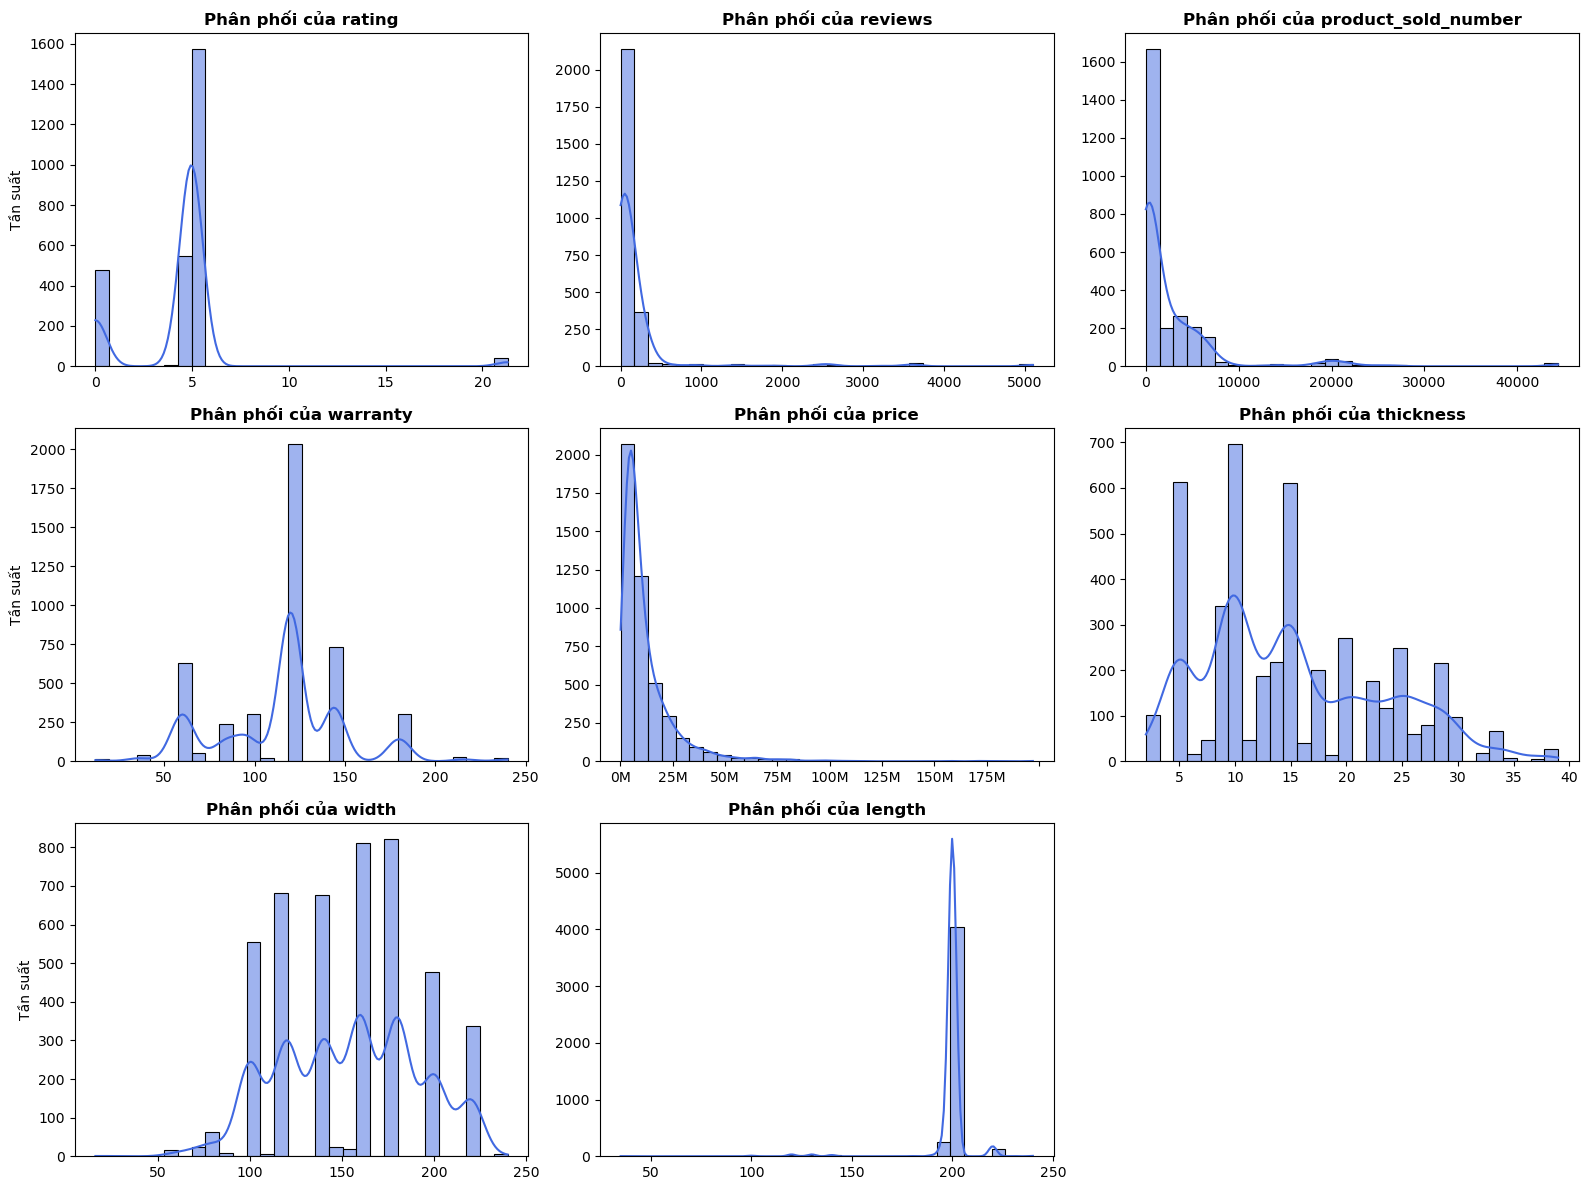

In [8]:

# 1. Tự động kiểm tra và định vị thư mục output (lùi ra ngoài 1 cấp từ thư mục notebooks/)
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

# Thiết lập số lượng cột và hàng cho lưới biểu đồ
n_cols = 3 
n_rows = math.ceil(len(num_cols) / n_cols)

# Tạo khung hình (Figure) lớn
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Lặp qua từng biến numerical để vẽ
for i, col in enumerate(num_cols):
    sns.histplot(data=mattress_df, x=col, kde=True, ax=axes[i], color='royalblue', bins=30)
    
    axes[i].set_title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Tần suất' if i % n_cols == 0 else '')
    
    if col == 'price':
        xticks = axes[i].get_xticks()
        axes[i].set_xticklabels([f'{int(x/1000000)}M' for x in xticks])

# Xóa bỏ các ô đồ thị trống
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# =========================================================================
# KHÓA SỔ: Xuất file ảnh chất lượng cao vào thư mục output của bạn
# bbox_inches='tight' giúp cắt sạch khoảng trắng thừa xung quanh biểu đồ
# =========================================================================
save_path = os.path.join(output_dir, "numerical_distributions.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"xuất thành công biểu đồ  tại: {save_path}")

plt.show()

### Nhận xét Phân tích Đơn biến (Univariate Analysis) - Nhóm Biến Định lượng

Dựa trên các chỉ số thống kê mô tả (Skewness, Kurtosis) và biểu đồ phân phối Histogram, đặc tính của dữ liệu nệm trên thị trường có thể được chia thành 3 nhóm quy luật cốt lõi:

#### 1. Nhóm Phân phối Lệch phải (Right-Skewed) - Quy luật thị trường
* **Các biến đại diện:** `price`, `reviews`, `product_sold_number`.
* **Đặc điểm:** Chỉ số độ lệch (Skewness) dương rất lớn (> 4), độ nhọn (Kurtosis) cao (> 23) và phân phối có phần đuôi (tail) kéo dài về phía bên phải.
* **Nhận xét nghiệp vụ:** * **Về Giá cả (`price`):** Phần lớn nệm trên thị trường tập trung ở phân khúc bình dân đến trung cấp (dưới 25.000.000 VNĐ). Phần đuôi dài phản ánh sự tồn tại của một nhóm nhỏ các sản phẩm thuộc phân khúc siêu cao cấp (Luxury) với mức giá có thể lên tới hơn 100 triệu đồng.
    * **Về Lượt bán & Đánh giá (`product_sold_number`, `reviews`):** Dữ liệu tuân thủ chặt chẽ nguyên lý Pareto (Quy luật 80/20). Đa số các dòng sản phẩm có vòng đời bán chậm với doanh số tà tà, trong khi một số rất ít các mã sản phẩm "quốc dân" lại sở hữu lượt mua và đánh giá áp đảo (hàng chục ngàn lượt).

#### 2. Nhóm Phân phối Đa đỉnh (Multimodal) - Tiêu chuẩn sản xuất
* **Các biến đại diện:** `thickness`, `width`, `warranty`.
* **Đặc điểm:** Skewness xoay quanh giá trị 0, phân phối không có dạng hình quả chuông (Normal Distribution) mà phân tách thành nhiều đỉnh (peaks) độc lập.
* **Nhận xét nghiệp vụ:** Các biến số này không biến thiên liên tục mà bị giới hạn bởi **Khuôn mẫu sản xuất công nghiệp chuẩn**.
    * Khối lượng dữ liệu tập trung thành các đỉnh rõ rệt ở các kích thước giường phổ thông: chiều rộng (`width`) thường là 120cm, 140cm, 160cm, 180cm, 200cm.
    * Tương tự, thời gian bảo hành (`warranty`) thường được các hãng quy định chẵn theo năm (5 năm = 60 tháng, 10 năm = 120 tháng), tạo ra các mốc dữ liệu cục bộ.

#### 3. Cảnh báo Dữ liệu Dị thường (Outliers) cần xử lý
Quá trình trực quan hóa đã chỉ ra các giá trị ngoại lai (Outliers) phát sinh từ khâu thu thập dữ liệu (Data Crawling) cần được loại bỏ trước khi đưa vào mô hình Học máy:
* **`rating` (Điểm đánh giá):** Tồn tại giá trị nhiễu vượt quá mức 20.0, vi phạm giới hạn thang điểm thương mại điện tử tiêu chuẩn (1.0 - 5.0).
* **`price` (Giá tiền):** Tồn tại các sản phẩm có mức giá cực thấp (dưới 100.000 VNĐ). Về mặt logic nghiệp vụ, đây có thể là lỗi thu thập nhầm các phụ kiện (vỏ bọc, gối) hoặc hàng tặng kèm, không phải nệm nguyên tấm.
* **`length` (Chiều dài):** Độ lệch âm nặng (-6.68) với đỉnh tập trung gần như tuyệt đối ở mức 200cm. Biến này mang rất ít giá trị phân loại (Variance thấp) do 95% nệm trên thị trường dùng chung một chuẩn chiều dài.

In [9]:
print(mattress_df[mattress_df['rating'] > 5.0].value_counts())

product_name                  brand   material_type                              category  description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [10]:
print(mattress_df['rating'][mattress_df['rating'] > 5.0].value_counts())

rating
21.3    42
Name: count, dtype: int64


In [11]:
# Ép các giá trị lỗi (> 5.0) về con số 5.0 thực tế đã tra cứu
mattress_df.loc[mattress_df['rating'] > 5.0, 'rating'] = 5.0

print("Phân phối rating:")
print(mattress_df['rating'].value_counts().sort_index(ascending=False).head(5))

Phân phối rating:
rating
5.0    1617
4.9     291
4.8     165
4.7      39
4.6      29
Name: count, dtype: int64


In [12]:
mattress_df[cat_cols].value_counts()

brand      material_type                                               category  origin    firmness             
Edena      Bông ép                                                     Bông ép   Việt Nam  Cứng                     151
Kim Cương  Cao su thiên nhiên                                          Cao su    Việt Nam  Trung bình - Hơi cứng    145
                                                                                           Trung bình               121
Everon     Bông ép                                                     Bông ép   Việt Nam  Cứng                     119
Liên Á     Cao su thiên nhiên                                          Cao su    Việt Nam  Trung bình - Hơi cứng    112
                                                                                                                   ... 
Kim Cương  Cao su thiên nhiên                                          Cao su    Việt Nam  Mềm - Trung bình           1
Oyasumi    Foam                                

/tmp/ipykernel_5861/1032484414.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([f'{int(x/1000000)}M' for x in xticks])


🎉 Đã xuất thành công lưới Boxplot tại: ../output/numerical_boxplots.png


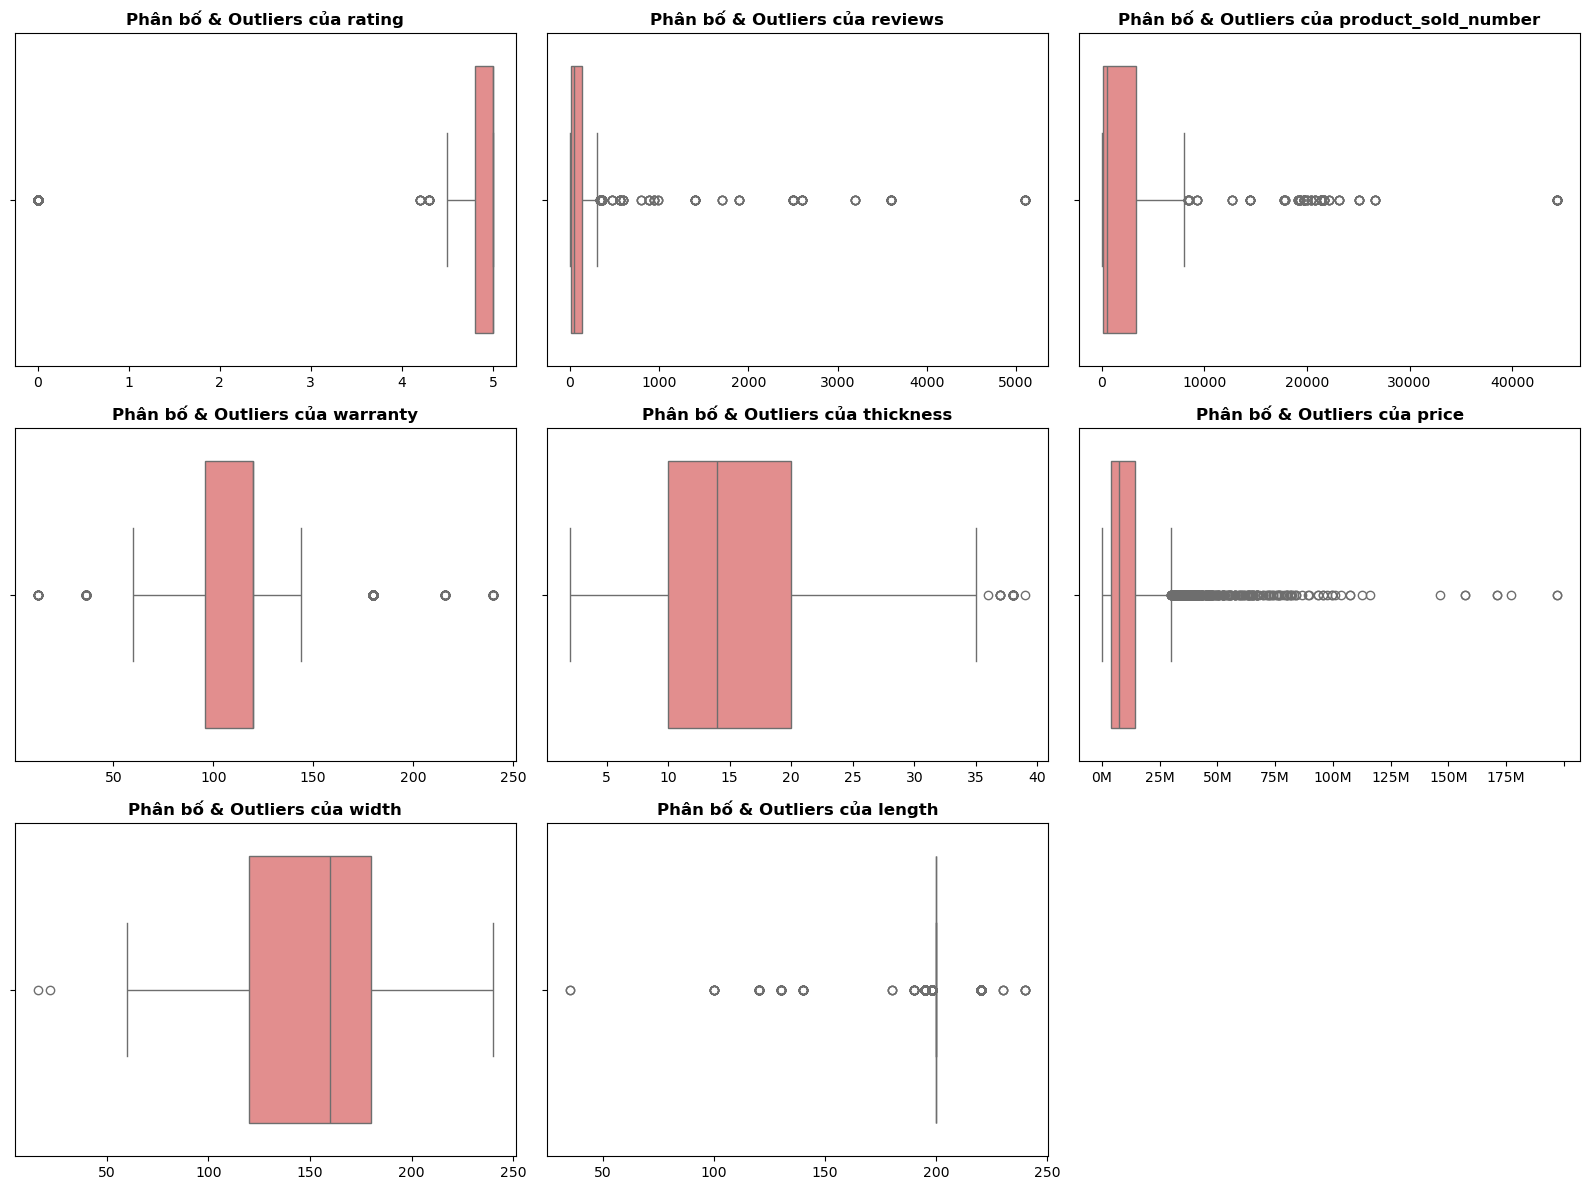

In [ ]:
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

num_cols_boxplot = mattress_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols = 3 
n_rows = math.ceil(len(num_cols_boxplot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_boxplot):
    sns.boxplot(data=mattress_df, x=col, ax=axes[i], color='lightcoral')
    
    axes[i].set_title(f'Phân bố & Outliers của {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

    if col == 'price':
        xticks = axes[i].get_xticks()
        axes[i].set_xticklabels([f'{int(x/1000000)}M' for x in xticks])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

save_path = os.path.join(output_dir, "numerical_boxplots.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Đã xuất thành công lưới Boxplot tại: {save_path}")

plt.show()

## 📊 Phân tích Phân bố & Outliers các biến số (Boxplot)

### 1. Rating
- Phân bố lệch trái mạnh — đa số sản phẩm có rating 4.5-5.0
- Có 1-2 outlier thấp (~1.0-2.0)
- **Selection bias:** các trang web thường chỉ hiển thị 
  sản phẩm bán chạy nên rating thường cao
- Không xử lý thêm, ghi nhận bias trong báo cáo

---

### 2. Reviews & Product Sold Number
- Phân bố lệch phải rất mạnh — đa số sản phẩm có ít 
  reviews/lượt bán, một số ít sản phẩm bán chạy vượt trội
- Reviews max ~5,000 | Product sold max ~40,000
- → **Cần Log Transform** ở bước Preprocessing

---

### 3. Warranty
- Phân bố tập trung 96-144 tháng (8-12 năm)
- Outlier thấp ~36-60 tháng (3-5 năm) và cao ~240 tháng (20 năm)
- Đây là giá trị hợp lệ — các hãng khác nhau có chính sách 
  bảo hành khác nhau
- Không xử lý thêm 

---

### 4. Thickness 
- Phân bố tập trung 10-20cm — hợp lý với thị trường nệm
- Phát hiện lỗi crawl: `"7.5cm"` bị parse thành `75` 
  do thiếu xử lý dấu thập phân
- **Đã fix:** chia 10 nếu value > 40 → max hiện tại ~40cm 
- Còn một số outlier nhỏ ~35-40cm → nệm cao cấp dày, hợp lệ

---

### 5. Price
- Phân bố lệch phải rất mạnh
- Đa số sản phẩm dưới 25 triệu | Outlier cao đến ~175 triệu
- Outlier là nệm cao cấp nhập khẩu thật sự 
  (Tempur, King Koil, Dunlopillo) — không xóa
- → **Cần Log Transform** ở bước Preprocessing

---

### 6. Width
- Phân bố tập trung 120-180cm (kích thước phổ biến). 
- Các giá trị ngoại lai thấp (<70cm) đã được kiểm chứng thuộc phân khúc Nệm trẻ em (Baby Mattresses). 
- Dữ liệu hợp lệ, giữ nguyên.
---

### 7. Length
- Phân bố tập trung quanh 200cm. 
- Các giá trị ngoại lai thấp (<150cm) hoàn toàn khớp với tập sản phẩm Nệm trẻ em đã được phân lập ở bước Cleaning. 
- Dữ liệu hợp lệ, giữ nguyên.

---

### Tổng kết — Hướng xử lý ở Preprocessing

| Cột | Vấn đề | Xử lý |
|-----|--------|-------|
| `rating` | Lệch trái, selection bias | Giữ nguyên, ghi nhận bias |
| `reviews` | Lệch phải, outlier | Log Transform |
| `product_sold_number` | Lệch phải, outlier | Log Transform |
| `warranty` | Outlier nhẹ, hợp lệ | StandardScaler |
| `thickness` | Đã fix lỗi crawl | StandardScaler |
| `price` | Lệch phải mạnh | Log Transform |
| `width` | Outlier nhẹ, hợp lệ | StandardScaler |
| `length` | Cần kiểm tra outlier thấp | StandardScaler |

In [14]:
# Kiểm tra các giá trị bất thường
print("=== LENGTH bất thường ===")
print(mattress_df[mattress_df['length'] < 100][
    ['product_name', 'width', 'length', 'thickness']
])

print("\n=== WIDTH bất thường ===")
print(mattress_df[mattress_df['width'] < 90][
    ['product_name', 'width', 'length', 'thickness']
])

print("\n=== THICKNESS bất thường ===")
print(mattress_df[mattress_df['thickness'] > 40][
    ['product_name', 'width', 'length', 'thickness']
])

=== LENGTH bất thường ===
                          product_name  width  length  thickness
865  Nệm cao su em bé Tatana Baby Care   16.0    35.0        NaN
866  Nệm cao su em bé Tatana Baby Care   22.0    35.0        NaN

=== WIDTH bất thường ===
                                     product_name  width  length  thickness
847             Nệm cao su em bé Tatana Baby Care   60.0   100.0        2.0
848             Nệm cao su em bé Tatana Baby Care   60.0   100.0        NaN
849             Nệm cao su em bé Tatana Baby Care   60.0   120.0        2.0
850             Nệm cao su em bé Tatana Baby Care   60.0   120.0        NaN
851             Nệm cao su em bé Tatana Baby Care   70.0   120.0        2.0
...                                           ...    ...     ...        ...
4177         Max - Nệm Lò Xo Túi Độc Lập Romantic   80.0   200.0       25.0
4282            Nệm Lò Xo Romantic Vải Gấm 2 Viền   80.0   200.0       24.0
4321  Nệm Lò Xo Cao Cấp Romantic - Vải Gấm 3 Viền   80.0   200.0     

/tmp/ipykernel_5861/3254058391.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[i], palette='Set2')
/tmp/ipykernel_5861/3254058391.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[i], palette='Set2')
/tmp/ipykernel_5861/3254058391.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[i], palette='Set2')
/tmp/ipykernel_5861/3254058391.py:29: FutureWarning: 

Passing `palette` without assigning `hu

🎉 Đã xuất thành công biểu đồ Categorical tại: ../output/categorical_distributions.png


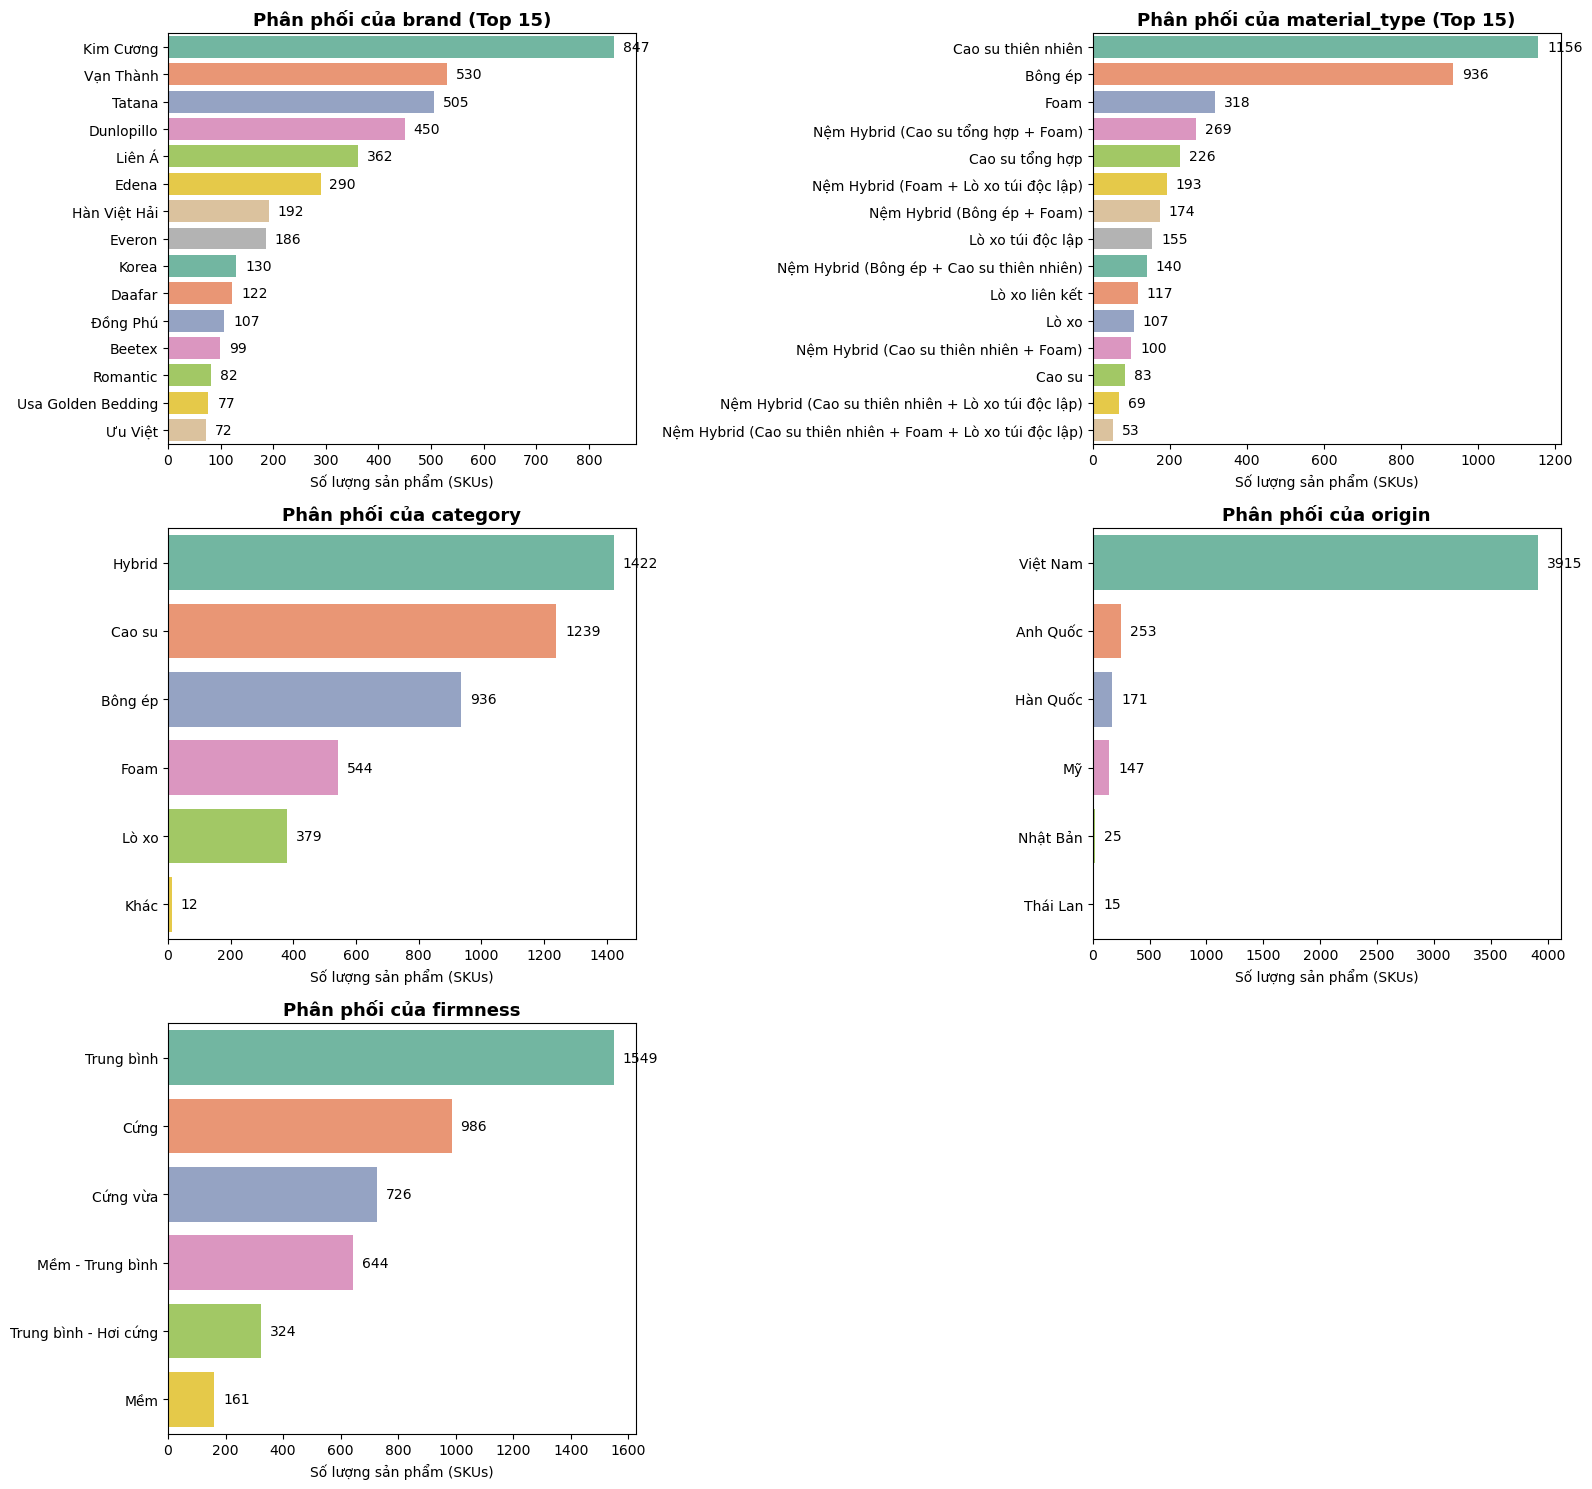

In [ ]:
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    val_counts = mattress_df[col].value_counts()

    if len(val_counts) > 15:
        plot_data = val_counts.nlargest(15)
        title_suffix = " (Top 15)"
    else:
        plot_data = val_counts
        title_suffix = ""

    sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[i], palette='Set2')
    
    # Định dạng tiêu đề và trục
    axes[i].set_title(f'Phân phối của {col}{title_suffix}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Số lượng sản phẩm (SKUs)')
    axes[i].set_ylabel('')
    
    # In trực tiếp con số lên đuôi mỗi cột
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_width())}', 
                         (p.get_width() + val_counts.max()*0.02, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', fontsize=10, color='black')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

save_path = os.path.join(output_dir, "categorical_distributions.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Đã xuất thành công biểu đồ Categorical tại: {save_path}")
plt.show()

In [16]:
mattress_df["origin"].value_counts()

origin
Việt Nam    3915
Anh Quốc     253
Hàn Quốc     171
Mỹ           147
Nhật Bản      25
Thái Lan      15
Name: count, dtype: int64

### Nhận xét Phân tích Đơn biến (Univariate Analysis) - Nhóm Biến Định danh (Categorical)

Sau quá trình làm sạch và chuẩn hóa (Data Cleansing & Standardization), phân tích phân phối của các biến định danh thông qua biểu đồ Barplot cho thấy bức tranh rõ nét về thị trường nệm, đồng thời khẳng định chất lượng tập dữ liệu đã sẵn sàng cho mô hình Học máy:

#### 1. Mức độ Cân bằng Dữ liệu (Data Balance) - Tối ưu cho Recommender System
* **Danh mục (`category`) & Hãng (`brand`):** Tập dữ liệu thể hiện sự phân mảnh và đa dạng rất tốt. Top các thương hiệu dẫn đầu (Kim Cương, Vạn Thành, Tatana, Dunlopillo) chiếm thị phần lớn nhưng không có hiện tượng độc quyền tuyệt đối. 
* Ở danh mục nệm, các nhóm Hybrid (1422), Cao su (1239), Bông ép (936) và Foam (544) có tỷ lệ phân bố tương đối đồng đều. **Nhận xét chuyên môn:** Việc duy trì được sự đa dạng này giúp Thuật toán Gợi ý (Recommender System) tránh được rủi ro thiên kiến (Bias), đảm bảo khả năng gợi ý phong phú và cá nhân hóa cao cho người dùng.

#### 2. Đặc tính Công thái học & Hành vi Tiêu dùng
* **Độ cứng (`firmness`):** Phân phối lệch rõ rệt về các nhóm "Trung bình" (1549), "Cứng" (986) và "Cứng vừa" (726), trong khi phân khúc nệm "Mềm" chỉ chiếm thiểu số (161 sản phẩm). Điều này phản ánh chính xác đặc điểm công thái học và thói quen bảo vệ cột sống của người tiêu dùng Á Đông nói chung và Việt Nam nói riêng.
* **Chất liệu (`material_type`):** Chất liệu (material_type): 'Cao su thiên nhiên' áp đảo thị trường với 1156 sản phẩm, theo sau là 'Bông ép' (936). Điều này hoàn toàn phản ánh đúng thị hiếu của người Việt Nam: ưa chuộng các vật liệu có nguồn gốc tự nhiên, độ bền cao và thoáng mát. Việc làm sạch và chuẩn hóa nhãn vật liệu chính xác giúp thuật toán không bị thiên lệch (bias) khi phân cụm các sản phẩm cao cấp.

#### 3. Bức tranh Chuỗi cung ứng & Xuất xứ (`origin`)
* Dữ liệu xuất xứ sau khi được chuẩn hóa Rule-based Mapping đã thể hiện sự phân tổ cực kỳ sắc nét. Thị trường chứng kiến sự áp đảo hoàn toàn của **Hàng nội địa Việt Nam** với 3915 SKUs (chiếm khoảng 86% tổng sản phẩm).
* Phần còn lại của thị trường thuộc về các sản phẩm nhập khẩu hoặc mang công nghệ từ các quốc gia phát triển như Anh Quốc (253), Hàn Quốc (171) và Mỹ (147). Sự phân bổ này cung cấp một Feature (Đặc trưng) rất tốt để thuật toán phân loại tệp khách hàng theo phân khúc: ưu tiên dùng hàng nội địa giá tốt hoặc ưa chuộng nệm ngoại nhập cao cấp.

## Phân tích song biến

/tmp/ipykernel_5861/213019098.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='price', y='category', palette='Set2')
/tmp/ipykernel_5861/213019098.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])


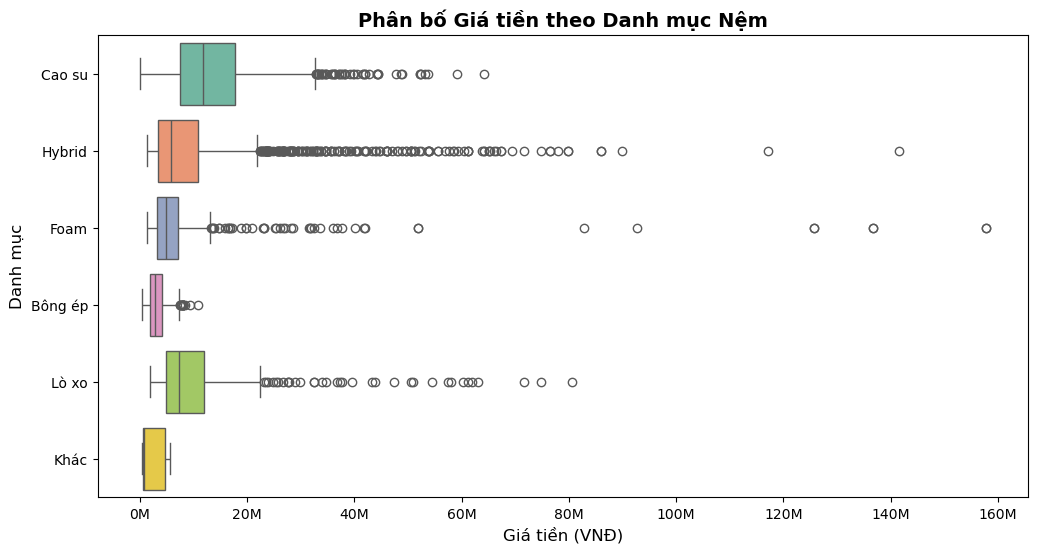

/tmp/ipykernel_5861/213019098.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='price', y='origin', palette='Set3')
/tmp/ipykernel_5861/213019098.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])


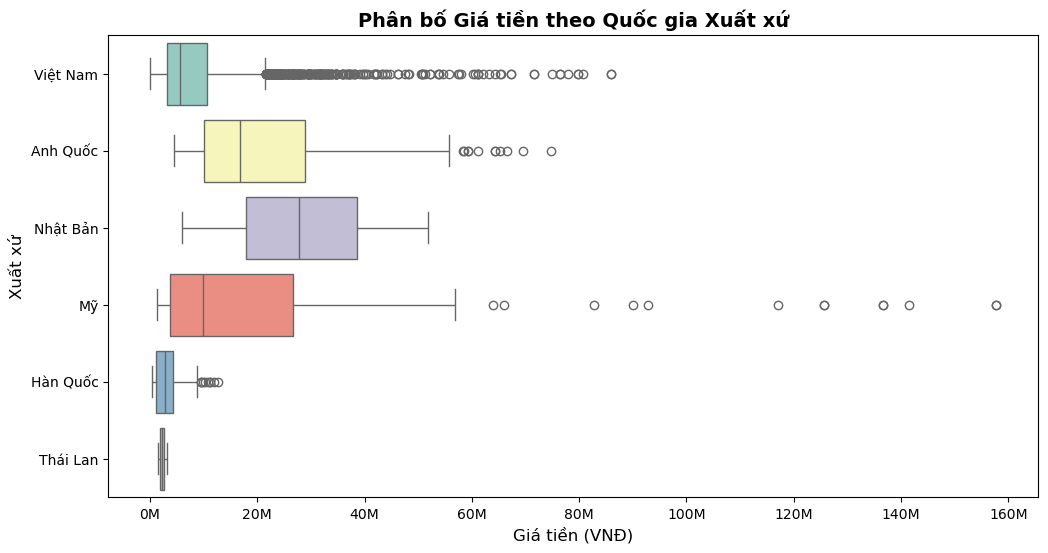

/tmp/ipykernel_5861/213019098.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_brands, x='price', y='brand', palette='pastel')
/tmp/ipykernel_5861/213019098.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])


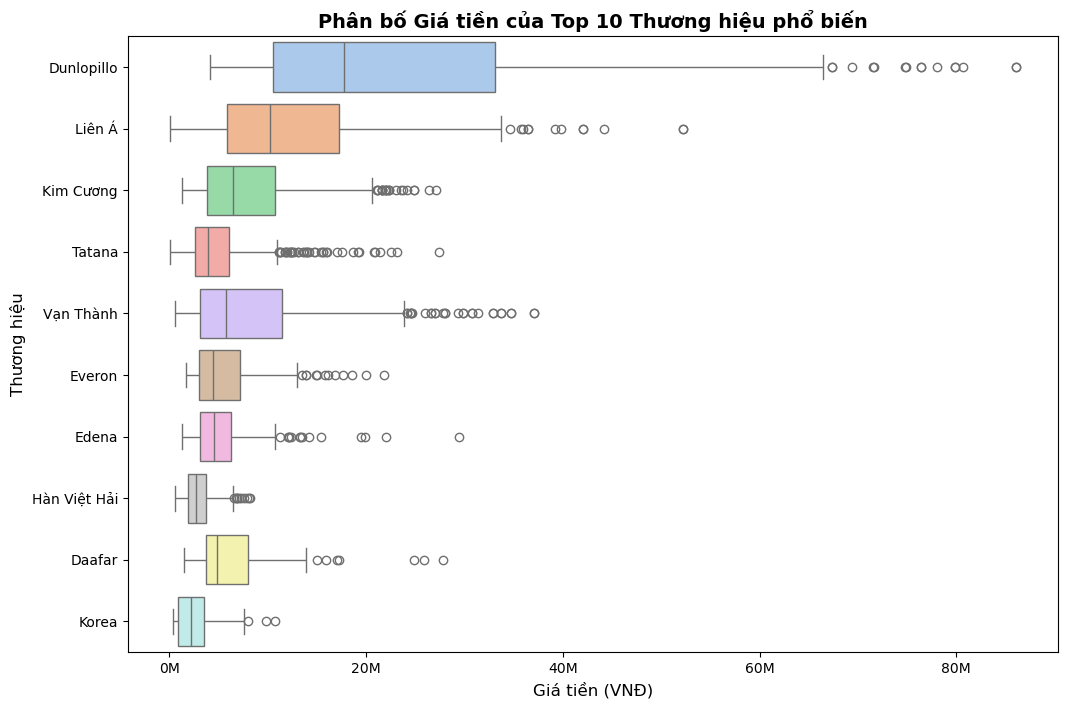

In [ ]:
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

df_plot = mattress_df[mattress_df['price'] > 0]

# Giá tiền vs Danh mục Nệm
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='price', y='category', palette='Set2')

plt.title('Phân bố Giá tiền theo Danh mục Nệm', fontsize=14, fontweight='bold')
plt.xlabel('Giá tiền (VNĐ)', fontsize=12)
plt.ylabel('Danh mục', fontsize=12)

# Format trục X sang đơn vị Triệu (M)
xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])

plt.savefig(os.path.join(output_dir, "boxplot_price_vs_category.png"), dpi=300, bbox_inches='tight')
plt.show()

# Giá tiền vs Xuất xứ (Origin)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='price', y='origin', palette='Set3')

plt.title('Phân bố Giá tiền theo Quốc gia Xuất xứ', fontsize=14, fontweight='bold')
plt.xlabel('Giá tiền (VNĐ)', fontsize=12)
plt.ylabel('Xuất xứ', fontsize=12)

xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])

plt.savefig(os.path.join(output_dir, "boxplot_price_vs_origin.png"), dpi=300, bbox_inches='tight')
plt.show()

# Giá tiền vs Top 10 Thương hiệu
plt.figure(figsize=(12, 8))
# Lọc lấy Top 10 thương hiệu lớn nhất để biểu đồ không bị rối
top_10_brands = df_plot['brand'].value_counts().nlargest(10).index
df_top_brands = df_plot[df_plot['brand'].isin(top_10_brands)]

sns.boxplot(data=df_top_brands, x='price', y='brand', palette='pastel')

plt.title('Phân bố Giá tiền của Top 10 Thương hiệu phổ biến', fontsize=14, fontweight='bold')
plt.xlabel('Giá tiền (VNĐ)', fontsize=12)
plt.ylabel('Thương hiệu', fontsize=12)

xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f'{int(x/1000000)}M' for x in xticks])

plt.savefig(os.path.join(output_dir, "boxplot_price_vs_brand.png"), dpi=300, bbox_inches='tight')
plt.show()

### Phân tích Song biến (Bivariate Analysis) - Mức độ ảnh hưởng của Đặc trưng đến Giá tiền

Thông qua biểu đồ Hộp (Boxplot), chúng ta có thể đánh giá chi tiết sự phân hóa giá trị sản phẩm (Price) khi đối chiếu chéo với các biến định danh cốt lõi (Category, Origin, Brand):

#### 1. Mối quan hệ giữa Giá tiền và Danh mục Nệm (Category)
* **Quy luật "Tiền nào của nấy":** Biểu đồ cho thấy sự phân tầng rõ rệt về giá trị vật liệu. Nệm **Bông ép** và phân khúc **Khác** nằm ở đáy của tháp giá, với hộp (IQR) rất hẹp và mức trung vị (median) bám sát ngưỡng dưới 5 triệu đồng, gần như không có sản phẩm ngoại lai giá cao.
* **Sự lên ngôi của Hybrid và Cao su:** Nệm **Cao su** và **Hybrid** định vị rõ ở phân khúc trung - cao cấp với mức trung vị dao động từ 10-15 triệu đồng. Đặc biệt, dòng Hybrid sở hữu dải giá trải rộng nhất và có những sản phẩm siêu cao cấp chạm ngưỡng 140 triệu đồng.
* **Sự phân hóa của Foam:** Dù mức giá trung vị của Foam thấp hơn Cao su, nhưng nó lại sở hữu những điểm ngoại lai (outliers) cực kỳ đắt đỏ (lên tới 160 triệu), phản ánh sự tồn tại của các dòng Memory Foam công nghệ cao.

#### 2. Mối quan hệ giữa Giá tiền và Xuất xứ (Origin)
* **Định vị hàng Ngoại nhập (Imported Premium):** Nệm có xuất xứ từ **Anh Quốc** và **Nhật Bản** định vị rõ ở phân khúc cao cấp với mức trung vị từ 15-25 triệu đồng. Riêng nệm xuất xứ từ **Mỹ** có mức trung vị dễ tiếp cận hơn (~10 triệu) nhưng lại sở hữu những điểm ngoại lai vươn tới mốc siêu cao cấp (160 triệu), đại diện cho các dòng nệm công nghệ độc quyền.
* **Chiến lược phủ rập của hàng Nội địa:** Nệm **Việt Nam** có mức trung vị thấp (phục vụ đại đa số người tiêu dùng bình dân), nhưng lại sở hữu một chuỗi "đuôi" ngoại lai rất dày đặc kéo dài đến 80 triệu đồng. Điều này chứng tỏ các thương hiệu nội địa không chỉ đánh vào giá rẻ mà còn liên tục tung ra các bộ sưu tập cao cấp để cạnh tranh trực tiếp với hàng ngoại.

#### 3. Mối quan hệ giữa Giá tiền và Thương hiệu (Brand Positioning)
Biểu đồ Top 10 thương hiệu lớn nhất đã "bóc tách" chính xác chiến lược kinh doanh của từng hãng:
* **Phân khúc Luxury:** **Dunlopillo** thể hiện vị thế độc tôn trong Top 10 với hộp giá rất dài, trung vị lên tới gần 20 triệu và các mã sản phẩm vươn tới gần 90 triệu đồng.
* **Trụ cột tầm trung (Mid-tier):** Bộ tứ **Liên Á, Kim Cương, Vạn Thành và Tatana** tạo thành xương sống của thị trường. Các hãng này duy trì mức trung vị vô cùng dễ tiếp cận (dao động 5-10 triệu) nhưng có độ trải giữa (IQR) đủ rộng kéo dài lên mốc 20-30 triệu để phục vụ đa dạng từ khách hàng bình dân đến trung-cao cấp.
* **Phân khúc giá rẻ (Budget):** Các thương hiệu như **Hàn Việt Hải, Daafar** và **Korea** nhắm thẳng vào phân khúc giá rẻ với biểu đồ hộp ngắn, trung vị dao động quanh 2-5 triệu và rất ít sự biến động về giá.

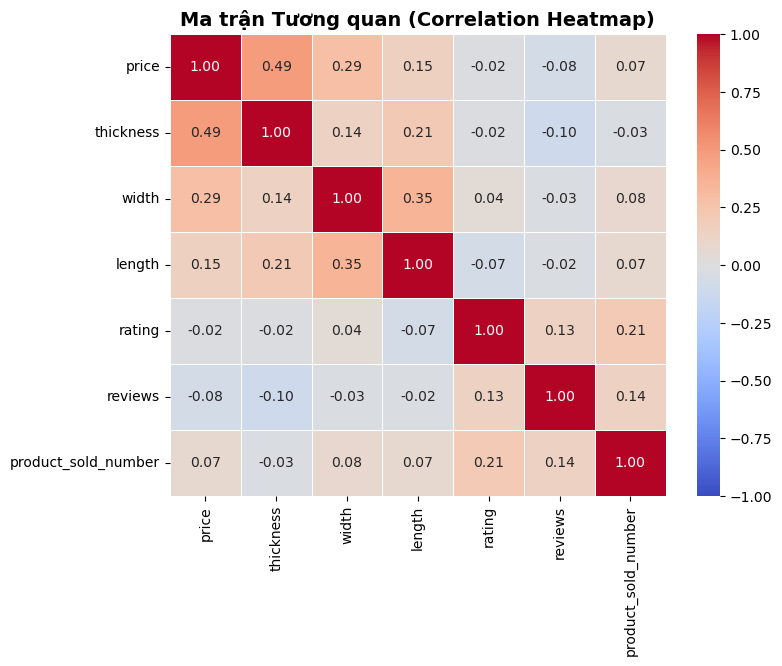

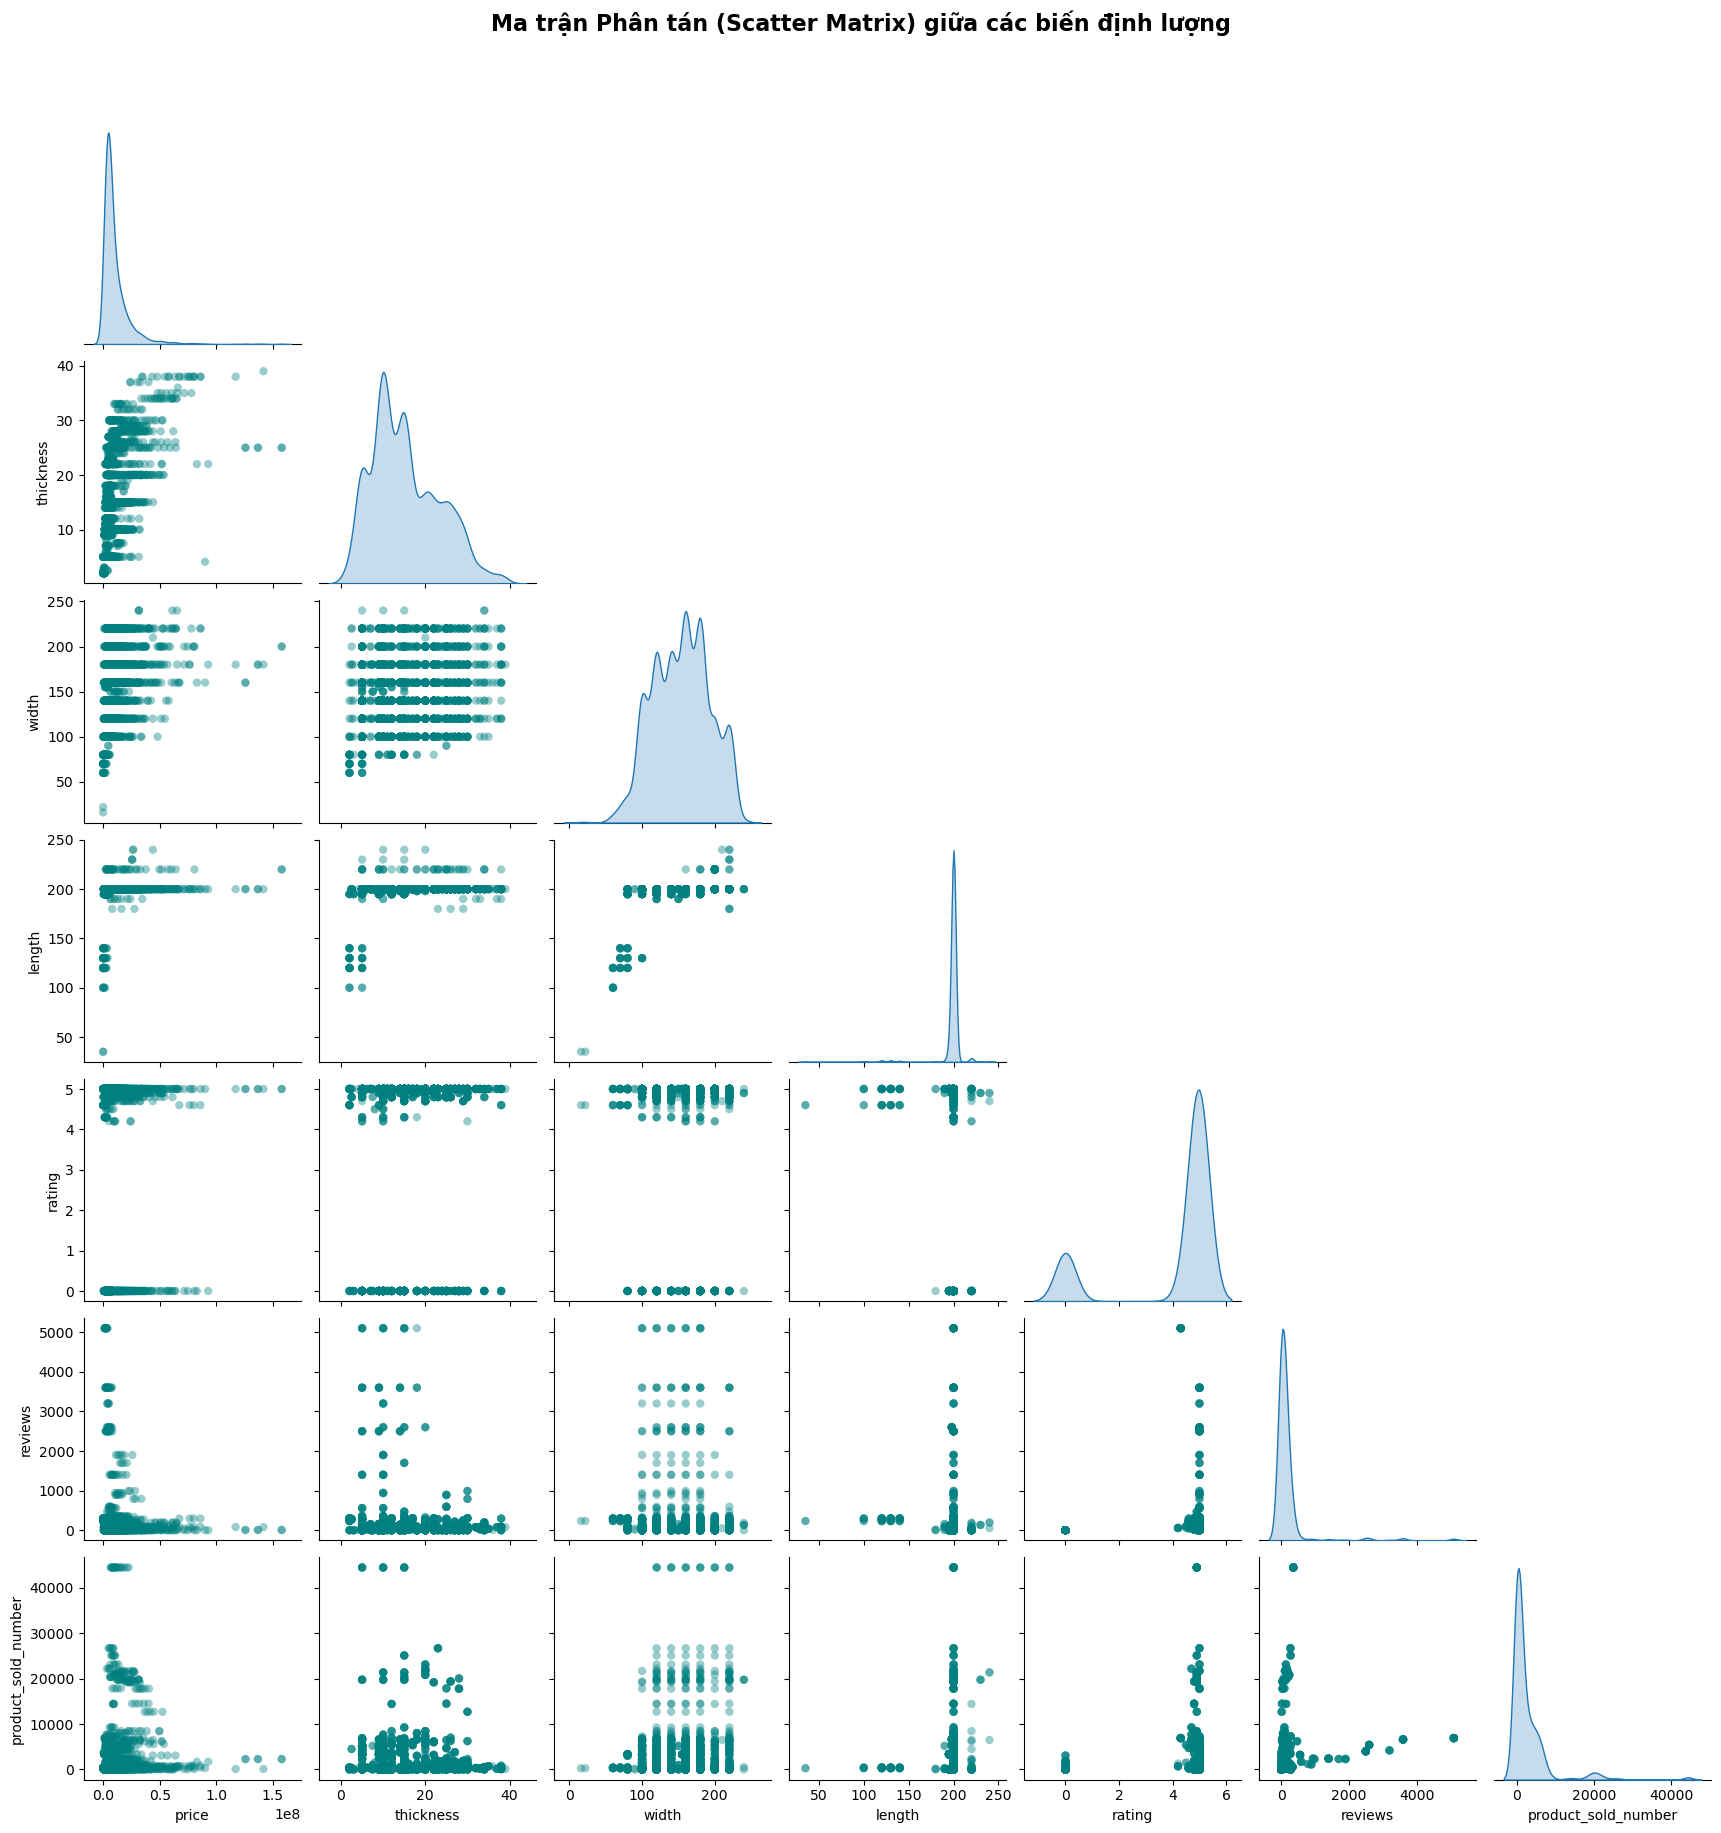

In [ ]:
num_cols = ['price', 'thickness', 'width', 'length', 'rating', 'reviews', 'product_sold_number']

df_plot = mattress_df[(mattress_df['price'] > 0) & (mattress_df['rating'] <= 5.0)]

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

# Biểu đồ heatmap (Ma trận tương quan)
plt.figure(figsize=(8, 6))
# Tính ma trận tương quan Pearson
corr_matrix = df_plot[num_cols].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1, center=0)

plt.title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(output_dir, "heatmap_correlation.png"), dpi=300, bbox_inches='tight')
plt.show()

# Biểu đồ scatter plot (Ma trận phân tán)
g = sns.pairplot(df_plot[num_cols], diag_kind='kde', corner=True, 
                 plot_kws={'alpha': 0.4, 'color': 'teal', 'edgecolor': 'none'})

g.fig.suptitle('Ma trận Phân tán (Scatter Matrix) giữa các biến định lượng', 
               y=1.05, fontsize=16, fontweight='bold')

plt.savefig(os.path.join(output_dir, "scatter_matrix.png"), dpi=300, bbox_inches='tight')
plt.show()

### Phân tích Tương quan & Khám phá Đa cộng tuyến (Correlation Analysis)

Thông qua Ma trận tương quan Pearson (Heatmap) và Ma trận phân tán (Scatter Matrix), chúng ta có thể đánh giá mức độ tuyến tính giữa các đặc trưng định lượng và rút ra các kết luận quan trọng cho mô hình:

#### 1. Kiểm định Đa cộng tuyến (Multicollinearity Check) - Kết quả: TỐT
* Một mô hình học máy khỏe mạnh đòi hỏi các biến đầu vào không được tương quan quá mạnh với nhau (thường ngưỡng nguy hiểm là > 0.8 hoặc < -0.8). 
* Nhìn vào Heatmap, cặp biến độc lập có hệ số tương quan cao nhất là `width` (chiều rộng) và `length` (chiều dài) với mức $r = 0.35$. Các cặp biến khác đều dao động ở mức rất thấp.
* **Kết luận:** Tập dữ liệu hoàn toàn không xảy ra hiện tượng Đa cộng tuyến (No Multicollinearity). Tất cả các biến định lượng đều mang thông tin độc lập và xứng đáng được giữ lại để huấn luyện mô hình.

#### 2. Phân tích Sức mạnh Dự đoán Giá tiền (Price Drivers)
* **Độ dày (`thickness`) là yếu tố quyết định nhất:** Với hệ số tương quan $r = 0.49$, đây là biến có tác động tuyến tính mạnh nhất đến giá. Biểu đồ Scatter phân tán của nó với `price` cũng cho thấy xu hướng phễu mở rộng: nệm càng dày thì trần giá càng vút lên cao. Về mặt vật lý, nệm dày đòi hỏi cấu trúc đa tầng (Hybrid) và tốn nhiều nguyên vật liệu cốt lõi (cao su, lò xo) nên chi phí sản xuất tăng vọt.
* **Kích thước bề mặt (`width`, `length`):** Có tác động tỷ lệ thuận nhưng khá yếu ($r = 0.29$ và $r = 0.15$). Lý do là chi phí gia tăng theo chiều ngang/dài không tốn kém bằng việc đắp thêm các tầng vật liệu tiện ích theo chiều dọc (độ dày).
* **Điểm đánh giá (`rating`):** Không có bất kỳ sự tương quan nào với giá tiền ($r = -0.02$). Một chiếc nệm bình dân vài triệu đồng hoàn toàn có thể nhận được đánh giá 5 sao y hệt một chiếc nệm trăm triệu, phụ thuộc vào trải nghiệm và kỳ vọng của phân khúc khách hàng đó.

#### 3. Đặc thù Hình học của Dữ liệu Nệm (Scatter Matrix)
* Biểu đồ phân tán giữa `width`, `length` và `thickness` không tạo thành các đám mây dữ liệu liên tục như các bộ dữ liệu thông thường. Thay vào đó, chúng xếp thành các **đường kẻ lưới (grid)** hoặc **các dải nằm ngang/dọc thẳng tắp**. 
* Hiện tượng này phản ánh tuyệt đối bản chất công nghiệp: Nệm không được sản xuất với kích thước ngẫu nhiên (ví dụ 163.5cm) mà bị "đóng khung" theo các khuôn đúc tiêu chuẩn (160x200, 180x200, dày 10cm, 15cm).

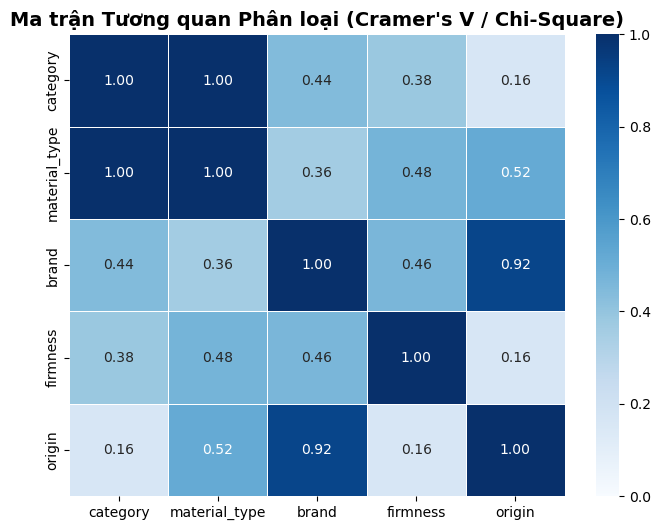

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

# Định nghĩa hàm tính toán hệ số Cramer's V (dựa trên Chi-Square)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0] # Trích xuất giá trị Chi-Square
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Tránh lỗi chia cho 0
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols_test = ['category', 'material_type', 'brand', 'firmness', 'origin']

cramer_matrix = pd.DataFrame(index=cat_cols_test, columns=cat_cols_test)

for col1 in cat_cols_test:
    for col2 in cat_cols_test:
        if col1 == col2:
            cramer_matrix.loc[col1, col2] = 1.0 # Đường chéo luôn bằng 1
        else:
            cramer_matrix.loc[col1, col2] = cramers_v(mattress_df[col1], mattress_df[col2])

# Ép kiểu dữ liệu về float để vẽ biểu đồ
cramer_matrix = cramer_matrix.astype(float)

# Biểu đồ heatmap cramer's V
plt.figure(figsize=(8, 6))
sns.heatmap(cramer_matrix, annot=True, cmap='Blues', fmt=".2f", 
            linewidths=0.5, vmin=0, vmax=1)

plt.title("Ma trận Tương quan Phân loại (Cramer's V / Chi-Square)", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(output_dir, "heatmap_cramers_v.png"), dpi=300, bbox_inches='tight')
plt.show()

### Nhận xét Kiểm định Chi-Square & Đo lường độ kết hợp Cramer's V 

### Phương pháp
Sử dụng hệ số **Cramer's V** để đo lường mức độ tương quan 
giữa các cặp biến phân loại (categorical). Giá trị từ 0 đến 1:
- `0.0 - 0.3`: Tương quan yếu
- `0.3 - 0.7`: Tương quan trung bình  
- `0.7 - 1.0`: Tương quan mạnh

---

### Nhận xét

**1. category ↔ material_type = 1.00 (Tương quan hoàn hảo)**

Hai cột hoàn toàn redundant — biết `category` là biết 
`material_type` và ngược lại. Điều này hợp lý vì `category` 
được extract trực tiếp từ `material_type` trong bước cleaning.

→ **Quyết định:** Chỉ dùng `material_type` làm feature cho model 
(chi tiết hơn, phù hợp TF-IDF). `category` chỉ dùng cho 
bộ lọc UI, không đưa vào feature vector.

---

**2. brand ↔ origin = 0.92 (Tương quan rất mạnh)**

Hầu hết thương hiệu gắn liền với một xuất xứ cố định 
(Dunlopillo → Singapore, Liên Á → Việt Nam...). 
Đưa cả 2 vào model gây multicollinearity.

→ **Quyết định:** Chỉ giữ `brand` làm feature cho model. 
`origin` dùng để hiển thị thông tin sản phẩm trên UI.

---

**3. Các cặp còn lại (0.16 - 0.52)**

Mức tương quan trung bình đến yếu — các biến này mang 
thông tin độc lập, có thể giữ lại làm feature cho model 
mà không lo multicollinearity.

---

### Tổng kết Feature Selection từ EDA

| Cột | Dùng cho Model | Dùng cho UI |
|-----|---------------|-------------|
| `material_type` | ✅ TF-IDF feature | ✅ Hiển thị chi tiết |
| `category` | ❌ Redundant với material_type | ✅ Filter dropdown |
| `brand` | ✅ One-hot encoding | ✅ Hiển thị |
| `origin` | ❌ Redundant với brand | ✅ Hiển thị |
| `firmness` | ✅ Feature | ✅ Filter |

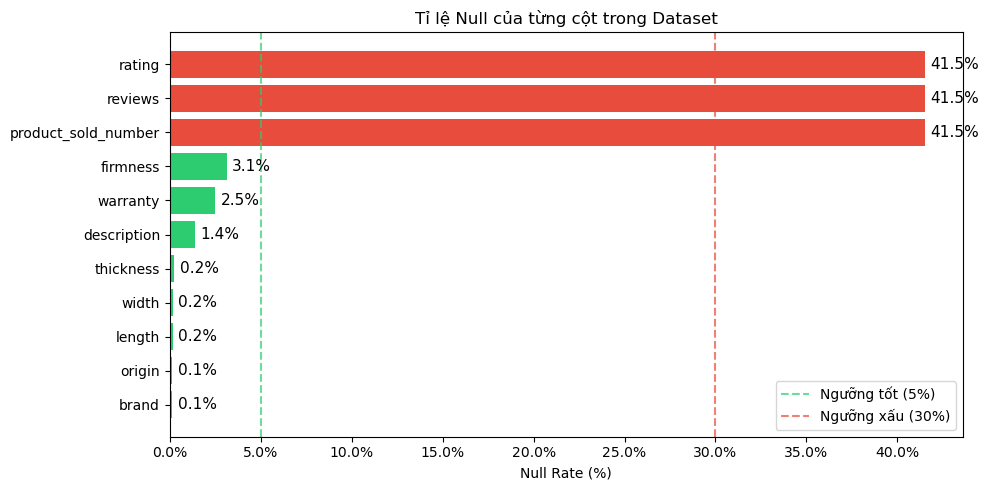

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)
# Tính null rate
null_rate = mattress_df.isnull().sum() / len(mattress_df) * 100
null_rate = null_rate[null_rate > 0].sort_values(ascending=True)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if x > 30 
          else '#f39c12' if x > 5 
          else '#2ecc71' 
          for x in null_rate.values]

bars = ax.barh(null_rate.index, null_rate.values, color=colors)

# Thêm label số liệu
for bar, val in zip(bars, null_rate.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11)

# Đường ngưỡng
ax.axvline(x=5,  color='#2ecc71', linestyle='--', 
           alpha=0.7, label='Ngưỡng tốt (5%)')
ax.axvline(x=30, color='#e74c3c', linestyle='--', 
           alpha=0.7, label='Ngưỡng xấu (30%)')

ax.set_xlabel('Null Rate (%)')
ax.set_title('Tỉ lệ Null của từng cột trong Dataset')
ax.legend()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "null_rate.png"), dpi=300, bbox_inches='tight')
plt.show()

## 📊 Phân tích Tỉ lệ Null (Null Rate)

### Biểu đồ Tỉ lệ Null từng cột

*(chèn biểu đồ vào đây)*

### Nhận xét

**Nhóm 1 — Null cao (> 30%) — Màu đỏ:**

Ba cột `rating`, `reviews`, `product_sold_number` 
đều có null rate 41.5%, toàn bộ đến từ nguồn 
**thegioigiuongnem.com** — trang này không hiển thị 
thông tin xã hội trên trang sản phẩm.

Hướng xử lý: Không impute — chỉ dùng 3 cột này 
để tính `popularity_score`. Sản phẩm không có 
thông tin sẽ nhận `popularity_score = None`.

---

**Nhóm 2 — Null chấp nhận được (< 5%) — Màu xanh:**

| Cột | Null Rate | Nguyên nhân |
|-----|-----------|-------------|
| `firmness` | 3.1% | thegioigiuongnem không hiển thị độ cứng |
| `warranty` | 2.5% | Một số sản phẩm không ghi rõ bảo hành |
| `description` | 1.4% | Một số sản phẩm thiếu mô tả |
| `thickness` | 0.2% | Không parse được từ chuỗi |
| `width` | 0.2% | Không parse được từ size |
| `length` | 0.2% | Không parse được từ size |
| `origin` | 0.1% | Một số sản phẩm không ghi xuất xứ |
| `brand` | 0.1% | Một số sản phẩm không xác định được brand |

Hướng xử lý:
- `firmness`: Đã impute theo kiến thức chuyên ngành 
  ở bước crawl
- Các cột còn lại: Giữ nguyên null, không impute 
  để tránh sai lệch

---

**Nhóm 3 — Không có null:**

Các cột quan trọng nhất cho model đều sạch hoàn toàn:
`product_name`, `material_type`, `category`, `price`

count    4532.000000
mean      652.276258
std       532.435845
min         0.000000
25%       283.000000
50%       490.000000
75%       819.000000
max      2251.000000
Name: desc_word_count, dtype: float64


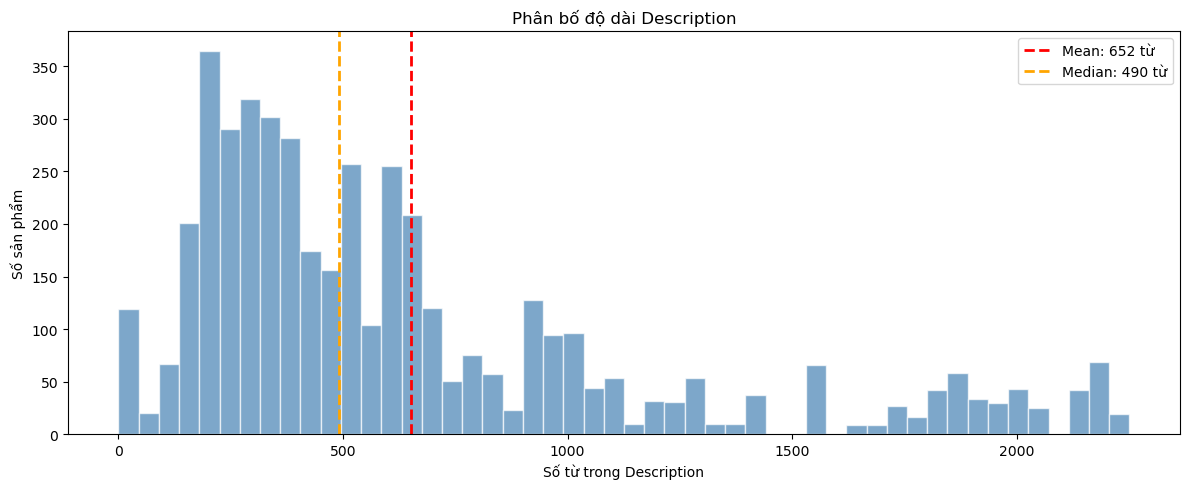

In [21]:
import matplotlib.pyplot as plt
import numpy as np

output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)
# Đếm số từ mỗi description
mattress_df['desc_word_count'] = mattress_df['description'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# Thống kê
print(mattress_df['desc_word_count'].describe())

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(mattress_df['desc_word_count'], bins=50, 
        color='steelblue', edgecolor='white', alpha=0.7)

# Vạch trung bình
mean_words = mattress_df['desc_word_count'].mean()
median_words = mattress_df['desc_word_count'].median()

ax.axvline(x=mean_words, color='red', 
           linestyle='--', linewidth=2,
           label=f'Mean: {mean_words:.0f} từ')
ax.axvline(x=median_words, color='orange',
           linestyle='--', linewidth=2,
           label=f'Median: {median_words:.0f} từ')

ax.set_xlabel('Số từ trong Description')
ax.set_ylabel('Số sản phẩm')
ax.set_title('Phân bố độ dài Description')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "desc_word_count.png"), dpi=300, bbox_inches='tight')
plt.show()

### Phân tích độ dài Description

- Mean: 652 từ | Median: 490 từ
- Phân bố lệch phải — đa số 100-700 từ
- Dựa trên median để chọn ra `max_features` tốt nhất 
  cho TF-IDF để capture đủ thông tin
  mà không gây nhiễu từ các từ hiếm gặp